# Mathematical Morphological (MM) Operations on Images - Exercise
_Mikołaj Leszczuk, Andrzej Matiolański_
![](https://i.creativecommons.org/l/by/4.0/88x31.png)

## Exercise - Erosion

Erosion is one of the two basic operators in the area of mathematical morphology, the other being dilation. It is typically applied to binary images, but there are versions that work on grayscale images. The basic effect of the operator on a binary image is to erode away the boundaries of regions of foreground pixels (i.e. white pixels, typically). Thus areas of foreground pixels shrink in size, and holes within those areas become larger.

### List of Functions Used in the Exercise and Their Descriptions

* `cv2.cvtColor(src, code)` - Converts an image from one color space to another.
* `cv2.erode(src, kernel)` - Erodes an image by using a specific structuring element.
* `cv2.imread(filename)` - Loads an image from a file.
* `cv2.threshold(src, thresh, maxval, type)` - Applies a fixed-level threshold to each array element.
* `np.ones(shape, dtype)` - Return a new array of given shape and type, filled with ones.
* `plt.imshow(X, cmap)` - Display data as an image, i.e., on a 2D regular raster.
* `plt.show()` - Display all open figures.

### Instruction

* Load our image into array. To do so you need to create a variable and load into it image (e.g. we will be using ‘`img8.png`’).
* We can see if the image is loaded properly.
* Our application will be operating on the black and white images using their array binary form. `255`’s stands for white color and `0`’s stands for black color. Convert our image into grayscale array and then into array containing `255`’s and `0`’s.
* See it.
* Next step is creating our `4 x 4` rectangular structuring element.
* Erode the image.

As a result of the code you should get something like this:

![](erode.png)

### Solution

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

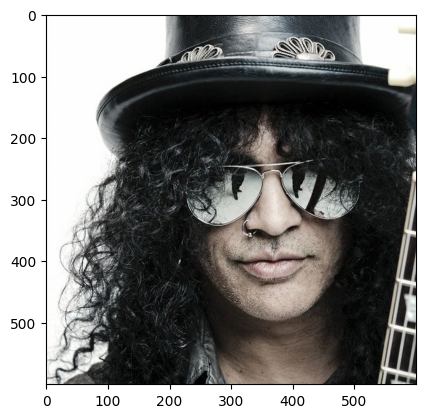

In [2]:
original = cv2.imread('images/img8.png')
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.show()

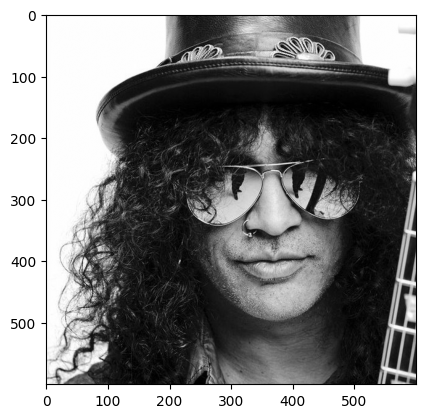

In [3]:
grayscale = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
plt.imshow(grayscale, cmap='gray')
plt.show()

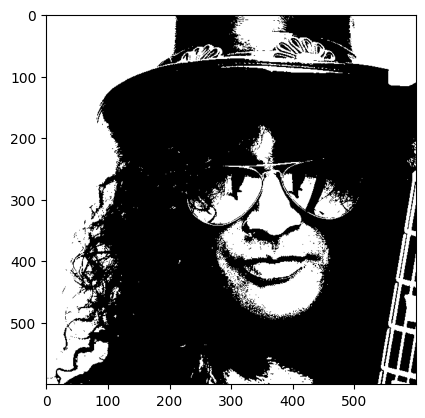

In [4]:
retval, binary = cv2.threshold(grayscale, thresh=128, maxval=255, type=cv2.THRESH_BINARY)
plt.imshow(binary, cmap='gray')
plt.show()

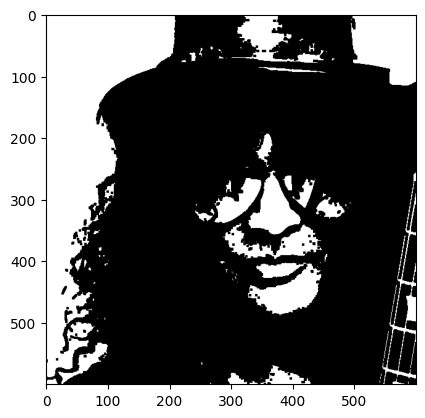

In [5]:
kernel = np.ones((4, 4), np.uint8)
eroded = cv2.erode(binary, kernel)
plt.imshow(eroded, cmap='gray')
plt.show()

## Exercise - Morphological Gradient (edge emphasis)
**Task:** Highlight edges by `gradient = dilate(img) - erode(img)`.
Try different structuring element sizes/shapes and compare.

In [6]:
img_path = 'images/img8.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

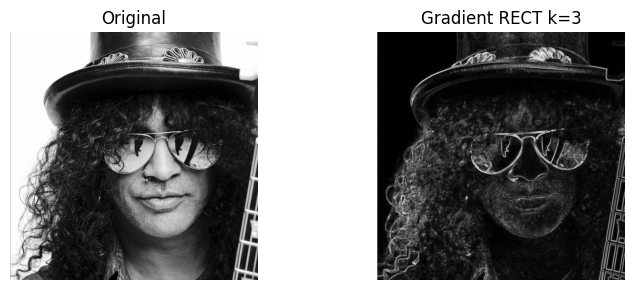

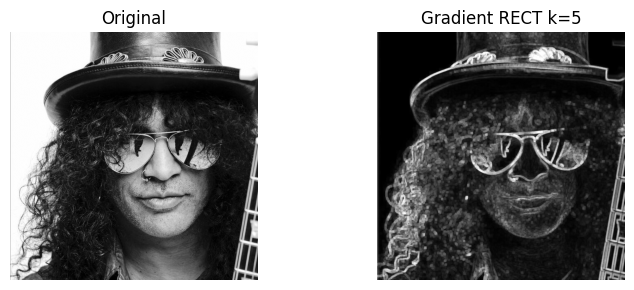

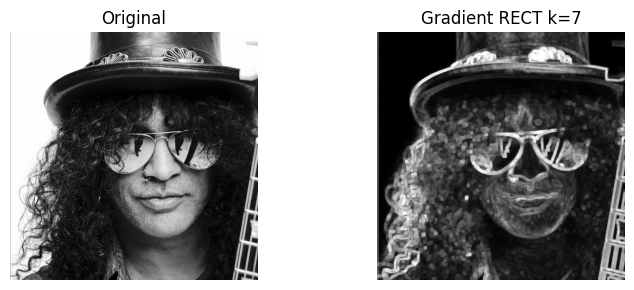

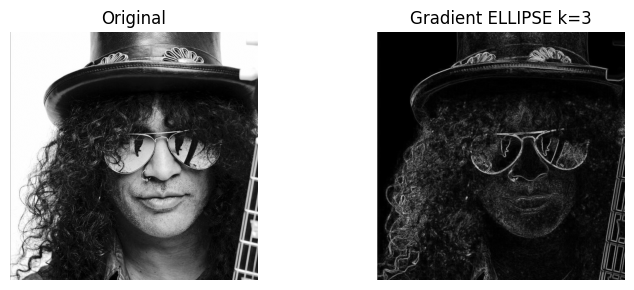

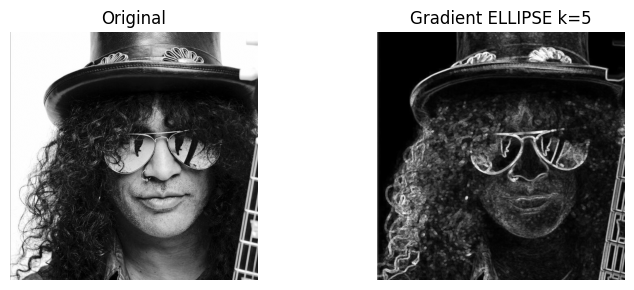

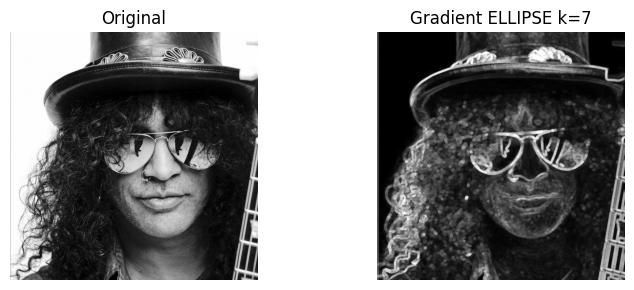

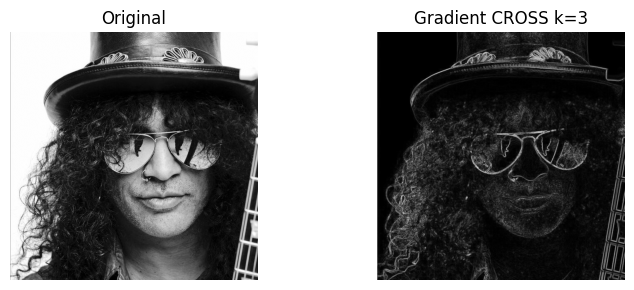

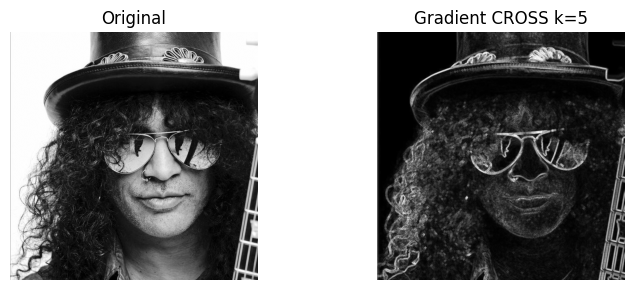

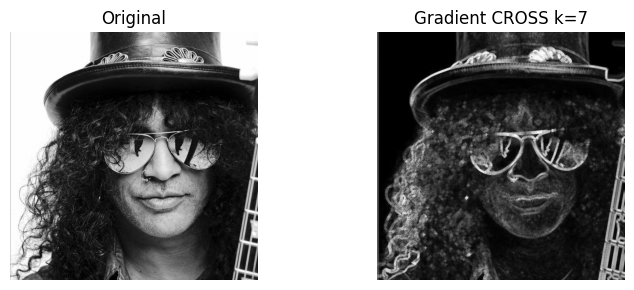

In [7]:
for shape_name, shape in {'RECT':cv2.MORPH_RECT,'ELLIPSE':cv2.MORPH_ELLIPSE,'CROSS':cv2.MORPH_CROSS}.items():
    for k in [3,5,7]:
        kernel = cv2.getStructuringElement(shape, (k,k))
        grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)
        plt.figure(figsize=(8,3))
        plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
        plt.subplot(1,2,2); plt.imshow(grad, cmap='gray'); plt.title(f'Gradient {shape_name} k={k}'); plt.axis('off')
        plt.tight_layout(); plt.show()

## Exercise - Hit-or-Miss (binary template matching)
**Task:** Detect a simple pattern in a binary image. Use `cv2.MORPH_HITMISS` or emulate with erosions on foreground/background masks.

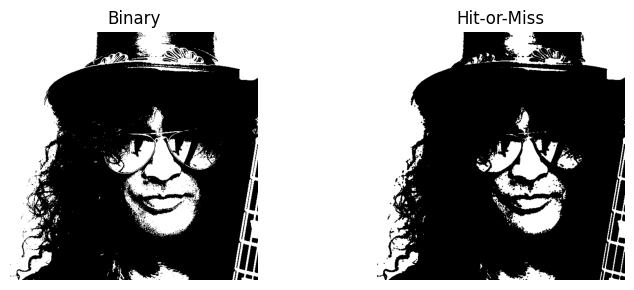

In [8]:
img_path = 'images/img8.png'
bin_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
_, bin_img = cv2.threshold(bin_img, 127, 255, cv2.THRESH_BINARY)
kernel = np.array([[0,1,0],[1,1,1],[0,1,0]], dtype=np.uint8)
hm = cv2.morphologyEx(bin_img, cv2.MORPH_HITMISS, kernel)
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); plt.imshow(bin_img, cmap='gray'); plt.title('Binary'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(hm, cmap='gray'); plt.title('Hit-or-Miss'); plt.axis('off')
plt.tight_layout(); plt.show()

## Exercise - Parameter Sweep (opening/closing vs. SE size & shape)
**Task:** Run opening/closing for RECT/ELLIPSE/CROSS with sizes {3,5,7}; pick the best combo for your image and justify.

In [9]:
img_path = 'images/img8.png'
bin_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
_, bin_img = cv2.threshold(bin_img, 127, 255, cv2.THRESH_BINARY)
shapes = {'RECT': cv2.MORPH_RECT, 'ELLIPSE': cv2.MORPH_ELLIPSE, 'CROSS': cv2.MORPH_CROSS}

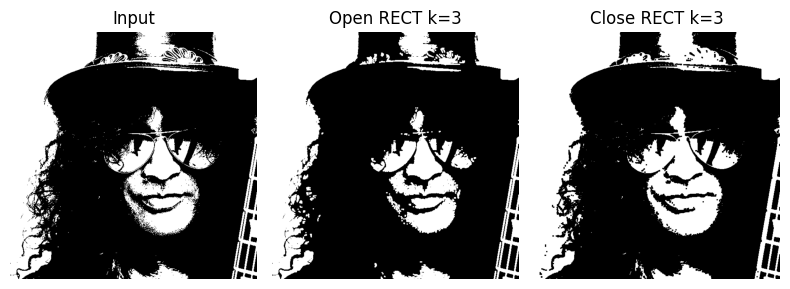

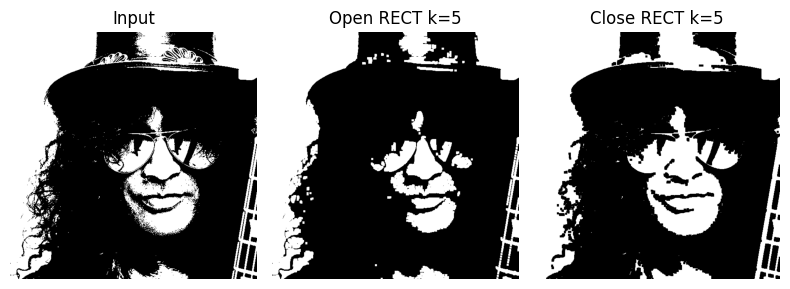

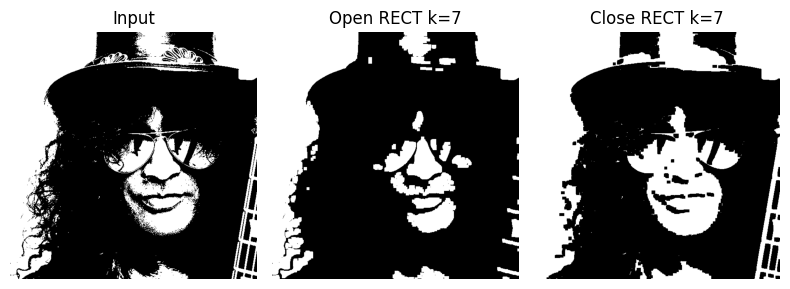

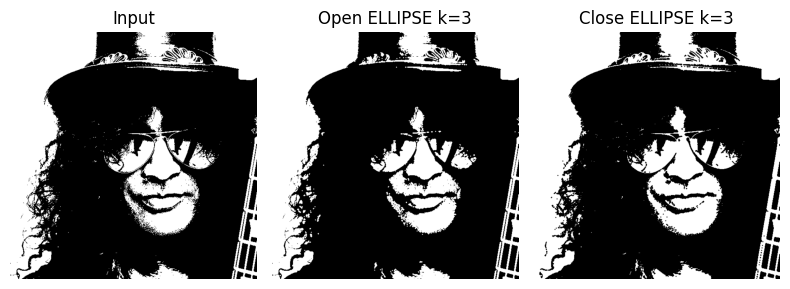

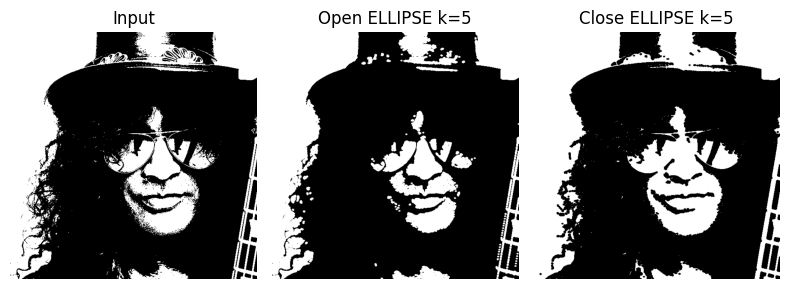

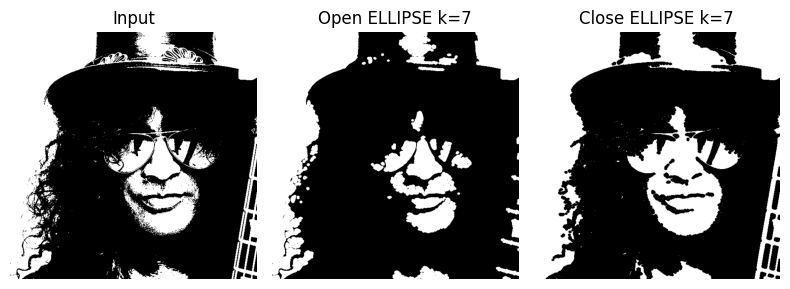

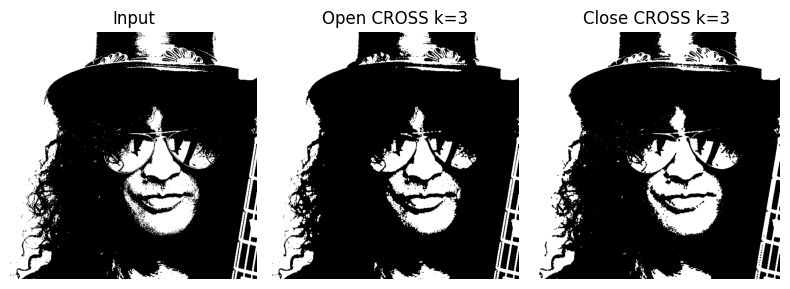

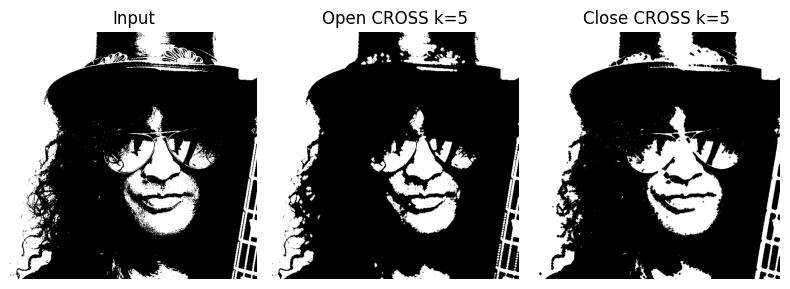

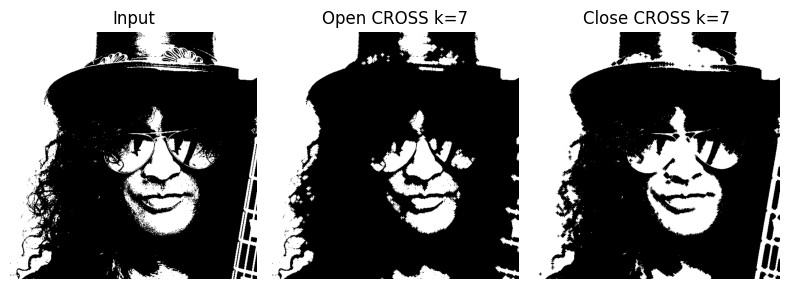

In [10]:
for name, stype in shapes.items():
    for k in [3,5,7]:
        kernel = cv2.getStructuringElement(stype, (k,k))
        opened = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel)
        closed = cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, kernel)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8,3))
        plt.subplot(1,3,1); plt.imshow(bin_img, cmap='gray'); plt.title('Input'); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(opened, cmap='gray'); plt.title(f'Open {name} k={k}'); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(closed, cmap='gray'); plt.title(f'Close {name} k={k}'); plt.axis('off')
        plt.tight_layout(); plt.show()

## Exercise - Mini‑Challenge: Clean & Count
**Task:** Clean noise (opening), then fill holes (closing), then label and count objects, then show colored labels. Report chosen SE.

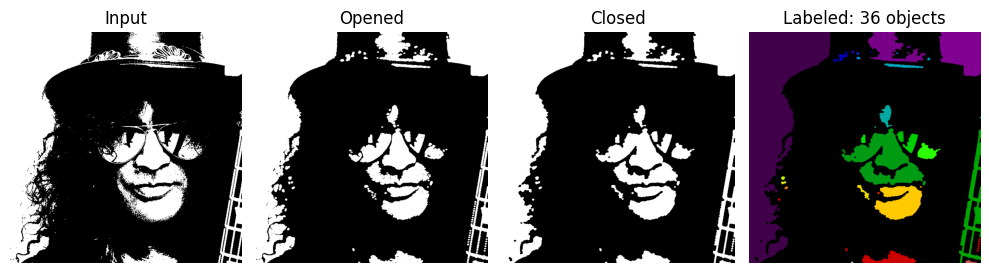

In [11]:
img_path = 'images/img8.png'
bin_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
_, bin_img = cv2.threshold(bin_img, 127, 255, cv2.THRESH_BINARY)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
opened = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
num, labels = cv2.connectedComponents((closed==255).astype(np.uint8))
label_img = (labels.astype(np.float32)/max(1,num-1))
plt.figure(figsize=(10,3))
plt.subplot(1,4,1); plt.imshow(bin_img, cmap='gray'); plt.title('Input'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(opened, cmap='gray'); plt.title('Opened'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(closed, cmap='gray'); plt.title('Closed'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(label_img, cmap='nipy_spectral'); plt.title(f'Labeled: {num-1} objects'); plt.axis('off')
plt.tight_layout(); plt.show()